In [12]:
import pandas as pd

import os

RECORDINGS_DIR = "./Recordings/"
TESTING = RECORDINGS_DIR + "/Testing/"

DIR_IN_USE = TESTING
vib_folder:list = os.listdir(DIR_IN_USE)

FILE_SAMPLES:int = 1 # len(vib_fold)

In [13]:
df:pd.DataFrame
for vib_file in vib_folder:  
    df = pd.read_csv(DIR_IN_USE + f"/{vib_file}", names=["AX", "AY", "AZ"])
df

,AX,AY,AZ
0,-0.75,-0.10,9.92
1,-0.72,-0.01,9.95
2,-0.81,-0.14,9.79
3,-0.78,-0.10,9.87
4,-0.75,-0.08,9.91
...,...,...,...
1184,-0.48,-0.34,9.90
1185,-0.40,-0.18,9.90
1186,-0.34,-0.11,9.99
1187,-0.38,-0.25,9.93


## Anomaly Detection with Simple Differencing

In [ ]:
df_diff = df.diff()
x_thres:float = 2
y_thres:float = 2
z_thres:float = 2

df_diff["Abnormal"] = (df_diff["AX"] > x_thres) | (df_diff["AY"] > y_thres) | (df_diff["AZ"] > z_thres)
df_diff.loc[df_diff["Abnormal"] == True] 


,AX,AY,AZ,Abnormal
142,1.37,0.43,2.13,True
146,2.09,1.50,2.89,True
149,-1.62,2.21,-0.02,True
151,2.05,-1.75,0.09,True
157,-2.21,2.45,-0.29,True
...,...,...,...,...
983,3.09,0.21,3.42,True
1015,-1.52,2.10,0.92,True
1026,-1.70,2.24,0.60,True
1056,3.18,-1.05,1.65,True


# FUTURE NOTE - This below is feature extraction, I didn't even realise I was doing a crucial prilimary step for AIRULE

# Advanced Techniques
Analysis of vibration signals which could be caused by ball bearing defects using time-domain statistical indicators (TDSI)
https://www.researchgate.net/publication/361885356_Analysis_of_vibration_signals_caused_by_ball_bearing_defects_using_time-domain_statistical_indicators#:~:text=Also%2C%20six%20new%20indicators%20developed,sensitive%20to%20defect%20size%20detection.&text=Content%20may%20be%20subject%20to%20copyright.&text=Content%20may%20be%20subject%20to%20copyright.,-International%20Journal%20of&text=work%20is%20properly%20cited.&text=domain%20%5B1%5D.&text=factor%2C%20impulse%20factor%2C%20shape%20factor,%5B1%5D.&text=compared%20to%20the%20evolution%20of%20bearing%20defect%20sizes.&text=TALAF%20are%20less%20sensitive%20to%20defect%20size%20detection.,-Keywords&text=Vibration%20signal%20analysis%2C%20Time%2Ddomain,Bearing%20defects%2C%20CWRU%20bearing%20data.&text=by%20%5B3%2C%204%5D.&text=abbreviations%20is%20shown%20in%20Appendix%20I.



## Peak

In [15]:
max_peak = df["AX"].max()

max_peak

11.68

### Root Mean Square (RMS) 

In [ ]:
import numpy as np


rms = np.sqrt(df["AX"].pow(2).sum())
rms

50.46049940299838

### Crest Factor (CS) - used for <strong>Early Fault Detection</strong>


In [17]:
cs = max_peak / rms
cs

0.23146818081840012

## Including Peak to Peak 

### Kurtosis - A scalar that indicates the presence of rare/outliers beyond the typical normal distribution.

### Histogram

array([[<Axes: title={'center': 'AX'}>, <Axes: title={'center': 'AY'}>],
       [<Axes: title={'center': 'AZ'}>, <Axes: >]], dtype=object)

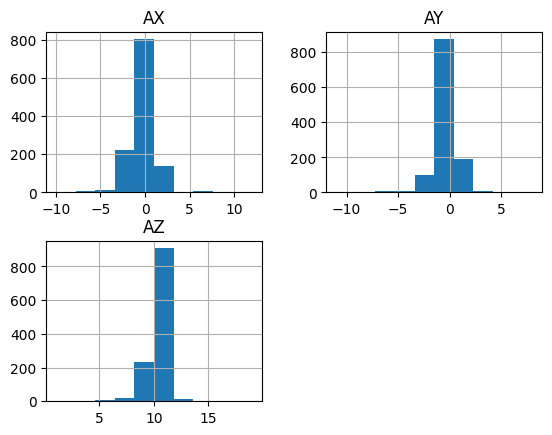

In [18]:
import matplotlib

df_round = df.round(0)
df_round.hist()